# Resumen de indicadores 2024-2026

Este notebook reproduce seis visualizaciones del tablero usando la tabla materializada en DuckDB. Las comparaciones entre años usan enero-agosto cuando es necesario incluir 2026.

In [1]:
from pathlib import Path
import duckdb
import matplotlib.pyplot as plt

db = Path('../data/processed/taxi.duckdb')
con = duckdb.connect(str(db), read_only=True)
plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
mensual = con.sql("""
    SELECT taxi_type, make_date(anio, mes, 1) AS mes, count(*) AS viajes
    FROM taxi_trips WHERE es_valido GROUP BY ALL ORDER BY mes
""").df()

comparacion = con.sql("""
    SELECT taxi_type, anio,
           count(*) / count(DISTINCT pickup_ts::DATE) AS viajes_por_dia,
           median(trip_distance) FILTER (WHERE trip_distance BETWEEN 0.01 AND 100) AS distancia_mediana,
           avg(total_amount) AS total_promedio,
           100.0 * count(*) FILTER (WHERE payment_type = 0 OR payment_type IS NULL) / count(*) AS pct_flex
    FROM taxi_trips
    WHERE es_valido AND mes BETWEEN 1 AND 8
    GROUP BY ALL ORDER BY taxi_type, anio
""").df()

calidad = con.sql("""
    SELECT taxi_type, anio, 100.0 * count(*) FILTER (WHERE NOT es_valido) / count(*) AS pct_invalidos
    FROM taxi_trips GROUP BY ALL ORDER BY taxi_type, anio
""").df()
comparacion

,taxi_type,anio,viajes_por_dia,distancia_mediana,total_promedio,pct_flex
0,green,2024,1809.483607,1.96,24.053365,3.939852
1,green,2025,1623.732510,2.02,25.026535,6.673898
2,green,2026,1380.415638,2.14,25.651154,14.429065
3,yellow,2024,106353.979508,1.80,28.446844,9.399954
4,yellow,2025,122290.395062,1.87,28.438411,20.426916
5,yellow,2026,121546.185185,1.92,30.399900,26.123190


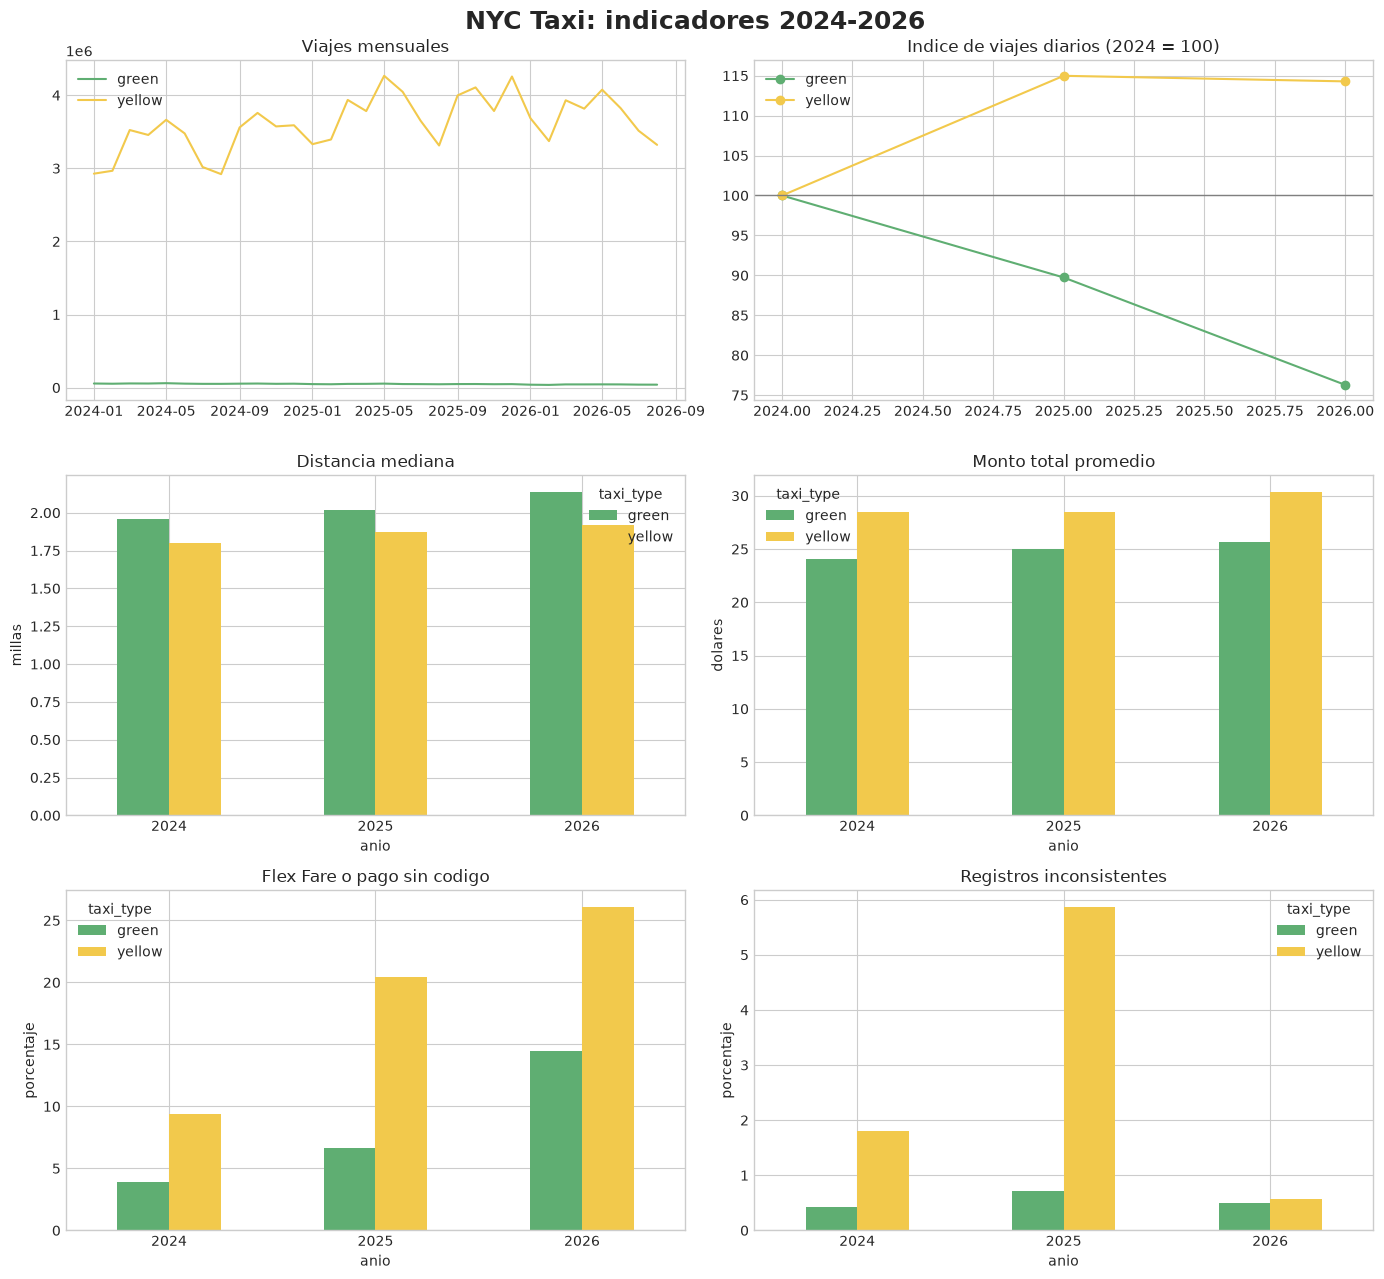

In [3]:
colores = {'yellow': '#f2c94c', 'green': '#5fae72'}
fig, axes = plt.subplots(3, 2, figsize=(14, 13))

for taxi, grupo in mensual.groupby('taxi_type'):
    axes[0, 0].plot(grupo['mes'], grupo['viajes'], label=taxi, color=colores[taxi])
axes[0, 0].set_title('Viajes mensuales')
axes[0, 0].legend()

for taxi, grupo in comparacion.groupby('taxi_type'):
    base = grupo.iloc[0]['viajes_por_dia']
    axes[0, 1].plot(grupo['anio'], 100 * grupo['viajes_por_dia'] / base, marker='o', label=taxi, color=colores[taxi])
axes[0, 1].axhline(100, color='gray', linewidth=1)
axes[0, 1].set_title('Indice de viajes diarios (2024 = 100)')
axes[0, 1].legend()

comparacion.pivot(index='anio', columns='taxi_type', values='distancia_mediana').plot.bar(ax=axes[1, 0], color=[colores['green'], colores['yellow']])
axes[1, 0].set_title('Distancia mediana')
axes[1, 0].set_ylabel('millas')

comparacion.pivot(index='anio', columns='taxi_type', values='total_promedio').plot.bar(ax=axes[1, 1], color=[colores['green'], colores['yellow']])
axes[1, 1].set_title('Monto total promedio')
axes[1, 1].set_ylabel('dolares')

comparacion.pivot(index='anio', columns='taxi_type', values='pct_flex').plot.bar(ax=axes[2, 0], color=[colores['green'], colores['yellow']])
axes[2, 0].set_title('Flex Fare o pago sin codigo')
axes[2, 0].set_ylabel('porcentaje')

calidad.pivot(index='anio', columns='taxi_type', values='pct_invalidos').plot.bar(ax=axes[2, 1], color=[colores['green'], colores['yellow']])
axes[2, 1].set_title('Registros inconsistentes')
axes[2, 1].set_ylabel('porcentaje')

for ax in axes.flat:
    ax.tick_params(axis='x', rotation=0)
fig.suptitle('NYC Taxi: indicadores 2024-2026', fontsize=18, fontweight='bold')
fig.tight_layout()
plt.show()

## Lectura rápida

Green pierde volumen en los dos cambios de año. Yellow crece en 2025 y se mantiene casi igual en 2026 al comparar enero-agosto. En ambos servicios aumentan la distancia mediana, el monto total y la participación de Flex Fare. La anomalía de calidad más visible es yellow 2025.